# **1. Perkenalan Dataset**

Dataset yang digunakan dalam eksperimen ini adalah **Heart Disease Prediction Dataset** yang diperoleh dari UCI Machine Learning Repository. Dataset ini berisi parameter klinis dari pasien yang digunakan untuk memprediksi keberadaan penyakit jantung (heart disease).

Fitur-fitur utama dalam dataset ini meliputi:
- `age`: Usia pasien (dalam tahun).
- `sex`: Jenis kelamin (1 = laki-laki, 0 = perempuan).
- `cp`: Tipe nyeri dada (chest pain type) (kategorikal multiclass: 0, 1, 2, 3).
- `trestbps`: Tekanan darah istirahat (resting blood pressure) (dalam mm Hg).
- `chol`: Kolesterol serum (dalam mg/dl).
- `fbs`: Gula darah puasa (fasting blood sugar) > 120 mg/dl (1 = true, 0 = false).
- `restecg`: Hasil elektrokardiografi istirahat (kategorikal multiclass: 0, 1, 2).
- `thalach`: Detak jantung maksimum yang dicapai.
- `exang`: Angina akibat olahraga (1 = yes, 0 = no).
- `oldpeak`: Depresi ST yang diinduksi oleh olahraga relatif terhadap istirahat.
- `slope`: Kemiringan segmen ST latihan puncak (kategorikal multiclass: 0, 1, 2).
- `ca`: Jumlah pembuluh darah utama (0-3) yang diwarnai dengan fluoroskopi.
- `thal`: Hasil tes thalasemia (kategorikal multiclass: 0, 1, 2, 3).
- `target`: Variabel target (1 = sakit jantung, 0 = normal).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Definisikan path data mentah
raw_data_path = '../namadataset_raw/heart.csv'
df = pd.read_csv(raw_data_path)
print(f"Dataset berhasil dimuat. Dimensi data: {df.shape}")

Dataset berhasil dimuat. Dimensi data: (303, 14)


In [3]:
# Menampilkan 5 baris pertama data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Menampilkan informasi dasar kolom, tipe data, dan missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Ringkasan statistik deskriptif untuk fitur numerik
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Distribusi kelas target:
target
1    165
0    138
Name: count, dtype: int64


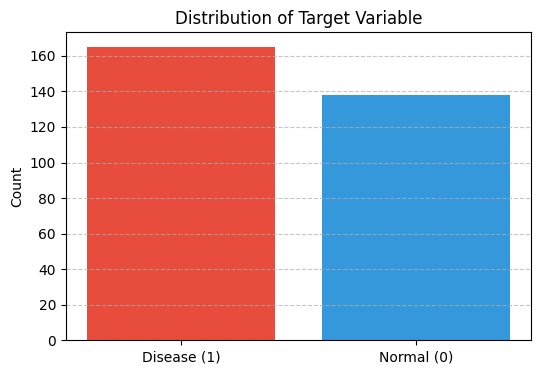

In [6]:
# Distribusi variabel target (heart disease vs normal)
target_counts = df['target'].value_counts()
print("Distribusi kelas target:")
print(target_counts)

plt.figure(figsize=(6, 4))
plt.bar(['Disease (1)', 'Normal (0)'], target_counts.values, color=['#e74c3c', '#3498db'])
plt.title('Distribution of Target Variable')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

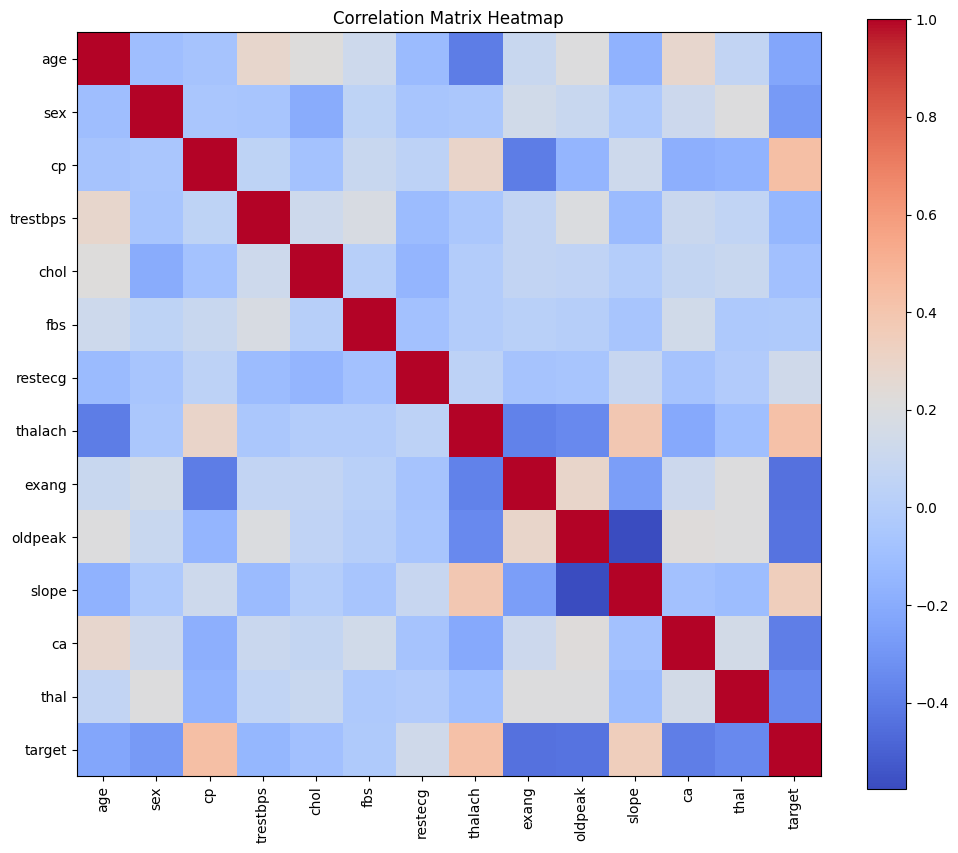

In [7]:
# Matriks Korelasi antar fitur
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title('Correlation Matrix Heatmap')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
# 1. Scaling Fitur Numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df_scaled.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.952197,1,3,0.763956,-0.256334,1,0,0.015443,0,1.087338,0,0,1,1
1,-1.915313,1,2,-0.092738,0.072199,0,1,1.633471,0,2.122573,0,0,2,1


In [9]:
# 2. One-hot Encoding Fitur Kategorik Multiclass
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df_preprocessed = pd.get_dummies(df_scaled, columns=categorical_cols, drop_first=True)

# Konversi tipe boolean ke 0/1 jika ada
for col in df_preprocessed.columns:
    if df_preprocessed[col].dtype == 'bool':
        df_preprocessed[col] = df_preprocessed[col].astype(int)

df_preprocessed.head(2)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,0.952197,1,0.763956,-0.256334,1,0.015443,0,1.087338,0,1,0,0,1,0,0,0,0,1,0,0
1,-1.915313,1,-0.092738,0.072199,0,1.633471,0,2.122573,0,1,0,1,0,1,0,0,0,0,1,0


In [10]:
# 3. Simpan data hasil preprocessing manual untuk verifikasi
output_dir = 'namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'heart_preprocessed.csv')
df_preprocessed.to_csv(output_path, index=False)
print(f"Data preprocessing manual berhasil disimpan ke: {output_path}")

Data preprocessing manual berhasil disimpan ke: namadataset_preprocessing\heart_preprocessed.csv


In [11]:
# 4. Menguji Skrip Otomatisasi Preprocessing
import automate_WincentCP as aut

# Jalankan pipeline dengan fungsi dari automate_WincentCP
test_df = aut.run_pipeline(raw_data_path, './namadataset_preprocessing/heart_preprocessed.csv')
print("Pengujian modul automate_WincentCP.py berhasil!")
test_df.head(2)

Preprocessed data saved to ./namadataset_preprocessing/heart_preprocessed.csv


Pengujian modul automate_WincentCP.py berhasil!


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,0.952197,1,0.763956,-0.256334,1,0.015443,0,1.087338,0,1,0,0,1,0,0,0,0,1,0,0
1,-1.915313,1,-0.092738,0.072199,0,1.633471,0,2.122573,0,1,0,1,0,1,0,0,0,0,1,0
